# Requirements

In [4]:
%%writefile requirements.txt
langchain
langgraph
langchain_community
langchain-community
langchain-core
langchain-openai
langchain-text-splitters
langchain-chroma
gradio
tavily
pypdf
tiktoken
arxiv
langsmith
wikipedia

Writing requirements.txt


In [5]:
!pip install -r requirements.txt

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.8/119.8 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 346.6/346.6 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 93.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.

## API Keys

In [ ]:
from langchain_classic.llms import OpenAI
import os
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get('OpenAI_API_key')

# Example-7 : Corrective RAG

In [ ]:
import os
from typing import Annotated, TypedDict, Literal
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain.chat_models import init_chat_model
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_core.messages import AnyMessage,HumanMessage,AIMessage
from langchain_core.tools.retriever import create_retriever_tool
from langgraph.graph import StateGraph,START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode,tools_condition

## RAG Steps

In [ ]:
# 1. Load Health Insurance PDF
PDF_PATH = "https://raw.githubusercontent.com/venkatareddykonasani/Datasets/master/Health_Insurance_Plan/Health%20Companion-Health%20Insurance%20Plan_GEN617.pdf"
loader = PyPDFLoader(PDF_PATH)
docs = loader.load()
#print(docs[0])

# 2. Split into chunks
splitter = RecursiveCharacterTextSplitter(
    chunk_size=700,
    chunk_overlap=100
)
chunks = splitter.split_documents(docs)
#print(chunks[0])

# 3. Create Embeddings and Store in Vector DB
embeddings = OpenAIEmbeddings()
vector_db = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    collection_name="health_insurance_policy"
)

# 4. Create Retriever
retriever = vector_db.as_retriever(
    search_kwargs={"k": 4}
)
print(
    retriever.invoke("What is the waiting period for pre-existing diseases?")
)

In [ ]:
#5. Define the LLM & State
llm=ChatOpenAI()

class agent_state(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

## Create Nodes

In [ ]:
# 6. Retriever Node
def retrieve(state: agent_state):
    print("---RETRIEVE FROM POLICY DOCUMENT---")
    question = state["messages"][0].content
    docs = retriever.invoke(question)
    all_docs = "\n\n".join([doc.page_content for doc in docs])
    return {
        "messages": [
            AIMessage(content=all_docs)
        ]
    }

In [ ]:
print(retrieve(agent_state(messages=[HumanMessage(content="What is covered under in-patient treatment?")])))

## Grade Documents - Node

In [ ]:
#7.Grade Documents - Conditional Node Function
GRADE_PROMPT = """
    You are a grader assessing relevance of a retrieved document to a user question.

    Here is the retrieved document:
    {context}

    Here is the user question:
    {question}

    If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant.
    Return no if: the context is only generally related and the answer would require guessing
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question

"""

def grade_documents(state: agent_state ) -> Literal["generate_answer", "rewrite_question"]:
    print("---GRADE RETRIEVED DOCUMENTS---")

    question = state["messages"][0].content
    context = state["messages"][-1].content

    prompt = GRADE_PROMPT.format(
        question=question,
        context=context
    )

    class Check_relevance(BaseModel):
      binary_score: str = Field(
        description="Return 'yes' if the retrieved context is relevant, otherwise return 'no'."
    )

    grader_llm = llm.with_structured_output(Check_relevance)

    response = grader_llm.invoke([
        HumanMessage(content=prompt)
    ])

    if response.binary_score.lower() == "yes":
        print("---DOCUMENTS ARE RELEVANT---")
        return "generate_answer"
    else:
        print("---DOCUMENTS ARE NOT RELEVANT---")
        return "rewrite_question"

## Rewrite Question - Node

In [ ]:
#8.Rewrite Question Node

REWRITE_PROMPT = """
Rewrite the user's question into a better search query for a health insurance policy document.
DO NOT Change the whole meaning of the question, just Formulate an improved question:

Original question:
{question}

Improved search query:
"""

def rewrite_question(state: agent_state):
    print("---REWRITE QUESTION---")
    question = state["messages"][0].content
    prompt = REWRITE_PROMPT.format(question=question)
    response = llm.invoke([
        HumanMessage(content=prompt)
    ])
    state["messages"][0].content=response.content
    print("Reframed Question ==> ", state["messages"][0].content)
    return state

## Generate Final Answer - Node

In [ ]:
#9.Generate Final Answer Node
GENERATE_PROMPT = """
You are a health insurance policy assistant.

Answer the question using only the retrieved policy context.

Rules:
1. Do not use outside knowledge.
2. If the answer is not present in the context, say:
   "I could not find this information in the policy document."
3. Keep the answer clear and concise.

Question:
{question}

Retrieved policy context:
{context}

Answer:
"""
def generate_answer(state: agent_state):
    print("---GENERATE ANSWER FROM RAG CONTEXT---")

    question = state["messages"][0].content
    context = state["messages"][-1].content

    prompt = GENERATE_PROMPT.format(
        question=question,
        context=context
    )
    response = llm.invoke([
        HumanMessage(content=prompt)
    ])

    return {
        "messages": [
            AIMessage(content=response.content)
        ]
    }

## Graph

In [ ]:
#10.Build Corrective RAG Agentic Workflow
workflow = StateGraph(agent_state)

workflow.add_node("retrieve", retrieve)
workflow.add_node("rewrite_question", rewrite_question)
workflow.add_node("generate_answer", generate_answer)

workflow.add_edge(START, "retrieve")

workflow.add_conditional_edges(
    "retrieve",
    grade_documents,
    {
        "generate_answer": "generate_answer",
        "rewrite_question": "rewrite_question"
    }
)

workflow.add_edge("rewrite_question", "retrieve")
workflow.add_edge("generate_answer", END)
graph = workflow.compile()

#Draw the graph
from IPython.display import display, Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
##11. Invoke the graph
response = graph.invoke({
    "messages": [
        HumanMessage(content="What is the waiting period for pre-existing conditions?")
    ]
})

print("\n--- FINAL ANSWER ---")
print(response["messages"][-1].content)

In [ ]:
# Test Cases

In [ ]:
test_questions = [
    "What is covered under in-patient treatment?",
    "What is the waiting period for pre-existing conditions?",
    "Are pre-hospitalization expenses covered?",
    "Are post-hospitalization expenses covered?",
    "Is ambulance expense covered?",
    "What is domiciliary treatment?",
    "Is dental treatment covered?",
    "What documents are required for reimbursement claim?",
    "What is the co-pay rule for insured persons aged 65 or above?",
    "What is the free look cancellation period?"
]

for i, question in enumerate(test_questions, start=1):
    print("\n" + "=" * 80)
    print(f"TEST CASE {i}: {question}")
    print("=" * 80)

    response = graph.invoke({
        "messages": [HumanMessage(content=question)]
    })

    print(response["messages"][-1].content)

**Practice work
\

```
# This is formatted as code
```

**

In [ ]:
## lets start with the basic lagchain retrivval operation
## 1 load the data
PDF_PATH = "https://raw.githubusercontent.com/venkatareddykonasani/Datasets/master/Health_Insurance_Plan/Health%20Companion-Health%20Insurance%20Plan_GEN617.pdf"
loader = PyPDFLoader(PDF_PATH)
docs = loader.load()

# 2 spilt the data into chunks
spliter = RecursiveCharacterTextSplitter(
    chunk_size=700,
    chunk_overlap=100
)
chunks = spliter.split_documents(docs)

#3 create the embeddings and vector Db

embeddings = OpenAIEmbeddings()
vector_db = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    collection_name="health_insurance_policy"
)

# 4 create the retreviver
retriever = vector_db.as_retriever(
    search_kwargs={"k": 4}
)
print(
    retriever.invoke("What is the waiting period for pre-existing diseases?")
)

#5 define the LLm and agent sate
llm = ChatOpenAI()

class agent_state(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

#6 create the retriver node
def retrieve(state: agent_state):
    print("---RETRIEVE FROM POLICY DOCUMENT---")
    question = state["messages"][0].content
    docs = retriever.invoke(question)
    all_docs = "\n\n".join([doc.page_content for doc in docs])
    # update the state return the context

    return {
        "messages": [
            AIMessage(content=all_docs)
        ]
    }


#7 Grade documents and conditaional node function
GRADE_PROMPT = """
    You are a grader assessing relevance of a retrieved document to a user question.

    Here is the retrieved document:
    {context}
    Here is the user question:
    {question}

    if the document content kewywords or semantic memory related to
    the user question , grade it as relevant
    """

# grade document routing function
def grade_documents(state: agent_state) -> Literal["generate_answer", "rewrite_question"]:
    print("---GRADE RETRIEVED DOCUMENTS---")


    question = state["messages"][0].content
    context = state["messages"][-1].content
    prompt = GRADE_PROMPT.format(
        question=question,
        context=context
    )
    # define the class of relevance checker
    class Check_relevance(BaseModel):
      binary_score: str = Field(
        description="Return 'yes' if the retrieved context is relevant, otherwise return 'no'."
    )

    grader_llm = llm.with_structured_output(Check_relevance)
    response = grader_llm.invoke([
        HumanMessage(content=prompt)
    ])
    if response.binary_score.lower() == "yes":
        print("---DOCUMENTS ARE RELEVANT---")
        return "generate_answer"
    else:
        print("---DOCUMENTS ARE NOT RELEVANT---")
        return "rewrite_question"

#8 rewrite node
REWRITE_PROMPT = """
Rewrite the user's question into a better search query for a health insurance policy document.
DO NOT Change the whole meaning of the question, just Formulate an improved question:

Original question:
{question}

Improved search query:
"""
# define the rewrite node
def rewrite_question(state: agent_state):
    print("---REWRITE QUESTION---")
    question = state["messages"][0].content
    prompt = REWRITE_PROMPT.format(question=question)
    #update the question
    response = llm.invoke([
        HumanMessage(content=prompt)
    ])
    state["messages"][0].content=response.content
    print("Reframed Question ==> ", state["messages"][0].content)
    return state

#9 generate answer node
GENERATE_PROMPT = """
You are a health insurance policy assistant.

Answer the question using only the retrieved policy context.
rules:
do not use outside knowledge
if the answer is not present in the context , say :
  "i could not find this information in the policy document."
keep the answer clear and concise.

question:
{question}
retrieved policy context:
{context}"""

def generate_answer(state: agent_state):
    print("---GENERATE ANSWER FROM RAG CONTEXT---")

    question = state["messages"][0].content
    context = state["messages"][-1].content
    #update
    prompt = GENERATE_PROMPT.format(
        question=question,
        context=context
    )
    response = llm.invoke([
        HumanMessage(content=prompt)
    ])

    return {
        "messages": [
            AIMessage(content=response.content)
        ]
    }



[Document(id='bc15f317-dcd9-43c6-9ba6-d98dcaddaf06', metadata={'creationdate': '2011-06-22T12:40:00+05:30', 'sourcemodified': 'D:20110616065908', 'creator': 'Acrobat PDFMaker 9.0 for Word', 'author': '', 'page_label': '10', 'source': 'https://raw.githubusercontent.com/venkatareddykonasani/Datasets/master/Health_Insurance_Plan/Health%20Companion-Health%20Insurance%20Plan_GEN617.pdf', 'company': '', 'page': 9, 'producer': 'Adobe Acrobat Pro DC (32-bit) 21 Paper Capture Plug-in', 'title': 'Terms & condition – Heart Beat                                                                               (A Preliminary Draft for Discussion Purpose only )', 'total_pages': 25, 'moddate': '2021-07-01T02:49:34+05:30'}, page_content='and shall be replaced entirely with the following: \n \n4(a) Pre-Existing Conditions \nBenefits will not be available for Pre- existing Conditions until the \ncompletion of the period stated in the Schedule of Insurance Certificate for  \nthe Insured Person.  It is unders

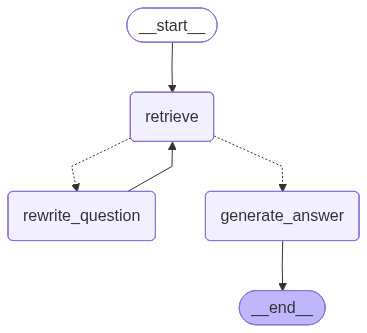

In [ ]:
# now build the graph
workflow = StateGraph(agent_state)

workflow.add_node("retrieve", retrieve)
workflow.add_node("rewrite_question", rewrite_question)
workflow.add_node("generate_answer", generate_answer)

# add the edges
workflow.add_edge(START, "retrieve")
# add conditional edge
workflow.add_conditional_edges(
    "retrieve",
    grade_documents,
    {
        "generate_answer": "generate_answer",
        "rewrite_question": "rewrite_question"
    }
)
workflow.add_edge("rewrite_question", "retrieve")
workflow.add_edge("generate_answer", END)
graph = workflow.compile()

#draw the graph
from IPython.display import display, Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# 11 test with multiple questions
test_questions = [
    "What is covered under in-patient treatment?",
    "What is the waiting period for pre-existing conditions?",
    "Are pre-hospitalization expenses covered?",
    "Are post-hospitalization expenses covered?",
    "Is ambulance expense covered?",
    "What is domiciliary treatment?",
    "Is dental treatment covered?",
    "What documents are required for reimbursement claim?",
    "What is the co-pay rule for insured persons aged 65 or above?",
    "What is the free look cancellation period?"
]

for i, question in enumerate(test_questions, start=1):
    print("\n" + "=" * 80)
    print(f"TEST CASE {i}: {question}")
    print("=" * 80)

    response = graph.invoke({
        "messages": [HumanMessage(content=question)]
    })

    print(response["messages"][-1].content)


TEST CASE 1: What is covered under in-patient treatment?
---RETRIEVE FROM POLICY DOCUMENT---
---GRADE RETRIEVED DOCUMENTS---


/usr/local/lib/python3.12/dist-packages/langchain_openai/chat_models/base.py:2394: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


---DOCUMENTS ARE RELEVANT---
---GENERATE ANSWER FROM RAG CONTEXT---
Treatment for which the Insured Person has to stay in a hospital for more than 24 hours for a covered event is covered under in-patient treatment. Any procedure undertaken on an out-patient basis in a Hospital will not be covered.

TEST CASE 2: What is the waiting period for pre-existing conditions?
---RETRIEVE FROM POLICY DOCUMENT---
---GRADE RETRIEVED DOCUMENTS---


/usr/local/lib/python3.12/dist-packages/langchain_openai/chat_models/base.py:2394: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


---DOCUMENTS ARE RELEVANT---
---GENERATE ANSWER FROM RAG CONTEXT---
period that would otherwise have been applicable from the inception of the first Policy with Us.

TEST CASE 3: Are pre-hospitalization expenses covered?
---RETRIEVE FROM POLICY DOCUMENT---
---GRADE RETRIEVED DOCUMENTS---


...

---DOCUMENTS ARE NOT RELEVANT---
---REWRITE QUESTION---
Reframed Question ==>  What is the co-payment policy for individuals aged 65 and above in the health insurance policy document?
---RETRIEVE FROM POLICY DOCUMENT---
---GRADE RETRIEVED DOCUMENTS---


/usr/local/lib/python3.12/dist-packages/langchain_openai/chat_models/base.py:2394: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


---DOCUMENTS ARE RELEVANT---
---GENERATE ANSWER FROM RAG CONTEXT---
i could not find this information in the policy document.

TEST CASE 10: What is the free look cancellation period?
---RETRIEVE FROM POLICY DOCUMENT---
---GRADE RETRIEVED DOCUMENTS---


/usr/local/lib/python3.12/dist-packages/langchain_openai/chat_models/base.py:2394: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


---DOCUMENTS ARE RELEVANT---
---GENERATE ANSWER FROM RAG CONTEXT---
You have a period of 15 days from the date of receipt of the Policy document to review the terms and conditions of this Policy. If you have any objections to any of the terms and conditions, you have the option of canceling the Policy within this free look period.


# Example-8: Reflection Agent

In [1]:
#!pip install arxiv

In [2]:
#Tavily key
import os
from google.colab import userdata
os.environ["TAVILY_API_KEY"] = userdata.get('Tavely_Api_Key')
os.environ["OPENAI_API_KEY"] = userdata.get('OpenAI_API_key')

In [6]:
from typing import TypedDict
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.tools.arxiv.tool import ArxivQueryRun
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage, HumanMessage, SystemMessage

/tmp/ipykernel_5230/2193076864.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


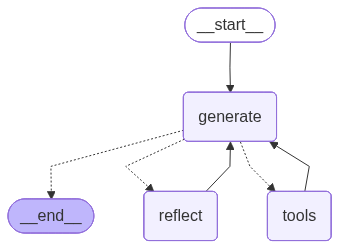

In [19]:
# parctice lets start with starting of the reflection agent

# 1 define the tools
search_tool = TavilySearchResults(max_results=3)
arxiv_tool = ArxivQueryRun()
tools = [search_tool,arxiv_tool]

# 2 define the llm
llm = ChatOpenAI()
llm_with_tools = llm.bind_tools(tools)

#3 define the state
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]
    reflection_count: int

#4 define the nodes and coondition
### generate node
def generate(state: AgentState):
    print("---GENERATE ---")
    response = llm_with_tools.invoke(state["messages"])
    return {
        "messages": [response]
    }

### define tools node
def tool_node(state: AgentState):
  print("---TOOLS---")
  all_tools=[search_tool]
  return ToolNode(tools=all_tools)

### reflect node
def reflect(state: AgentState):
    print("---REFLECT---")
    reflection_prompt = HumanMessage(
        content="""
        Review the previous answer.
        Improve factual accuracy, clarity and completeness.
        Then generate a better answer related to the question
        """
    )
    response = llm_with_tools.invoke(
        state["messages"] + [reflection_prompt]
    )
    return {
        "messages": [response],
        "reflection_count": state["reflection_count"] + 1
    }

  ## routing contions
def should_continue(state: AgentState):
    last_message = state["messages"][-1]
    # If tool call exists
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
      return "tools"
    # One reflection loop only
    if state["reflection_count"] < 1:
      return "reflect"
    return END

#5 now define the edges
workflow = StateGraph(AgentState)

workflow.add_node("generate", generate)
workflow.add_node("tools", tool_node)
workflow.add_node("reflect", reflect)


workflow.set_entry_point("generate")

workflow.add_conditional_edges(
    "generate",
    should_continue,
    {
        "tools": "tools",
        "reflect": "reflect",
        END: END
    }
)
workflow.add_edge("tools", "generate")
workflow.add_edge("reflect", "generate")
workflow.add_edge("generate", END)

# Compile
app = workflow.compile()

#draw
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [21]:
# invoke the app workflow with data
result = app.invoke({
    "messages": [
        HumanMessage(
            content="staock market predictio for tommarow in indian market ? "
        )
    ],
    "reflection_count": 0
})

---GENERATE ---
---TOOLS---
---GENERATE ---
---REFLECT---
---GENERATE ---


In [22]:
print(result['messages'][-1].content)

I found information related to the stock market prediction for tomorrow in the Indian market:

1. [India Stocks and The Bull Market's Next Phase | Morgan Stanley](https://www.morganstanley.com/ideas/india-election-stock-outlook):
   - The article discusses how India is predicted to experience a decade of record growth, potentially becoming the world's third-largest economy by 2027.
   - The stock market in India is expected to rank third globally by the end of the decade.
   - Private spending growth and a shift towards private investment are highlighted as key drivers for India's economic growth and stock market performance.

2. [Nifty Prediction & Bank Nifty Analysis for Monday | 15 June 2026](https://www.youtube.com/watch?v=fdzGrUdsqoE):
   - This video likely provides analysis and forecasts for the Indian stock market for June 15, 2026.

3. [NIFTY 50 Price: Quote, Forecast, Charts & News (^NSEI) - Perplexity](https://www.perplexity.ai/finance/%5ENSEI):
   - The Nifty 50 index showe

In [ ]:
#1. Tools
search_tool = TavilySearchResults(max_results=3)
arxiv_tool = ArxivQueryRun()
tools = [search_tool,arxiv_tool]

In [ ]:
#2. LLM and Tool binding
llm = ChatOpenAI()
llm_with_tools = llm.bind_tools(tools)

In [ ]:
#3. Define State
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]
    reflection_count: int

## Define Nodes

In [ ]:
#4.Generate Node
def generate(state: AgentState):
    print("---GENERATE ---")
    response = llm_with_tools.invoke(state["messages"])
    return {
        "messages": [response]
    }

In [ ]:
#5.Tool Node
def tool_node(state: AgentState):
  print("---TOOLS---")
  all_tools=[search_tool]
  return ToolNode(tools=all_tools)

## Reflection Node

In [ ]:
#6.Reflection Node
def reflect(state: AgentState):
    print("---REFLECT---")
    reflection_prompt = HumanMessage(
        content="""
        Review the previous answer.
        Improve factual accuracy, clarity and completeness.
        Then generate a better answer related to the question
        """
    )
    response = llm_with_tools.invoke(
        state["messages"] + [reflection_prompt]
    )
    return {
        "messages": [response],
        "reflection_count": state["reflection_count"] + 1
    }

In [ ]:
#7.Conditional Routing
def should_continue(state: AgentState):
    last_message = state["messages"][-1]
    # If tool call exists
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    # One reflection loop only
    if state["reflection_count"] < 1:
        return "reflect"
    return END

In [ ]:
#8. Graph

workflow = StateGraph(AgentState)

workflow.add_node("generate", generate)
workflow.add_node("tools", tool_node)
workflow.add_node("reflect", reflect)

workflow.set_entry_point("generate")

workflow.add_conditional_edges(
    "generate",
    should_continue,
    {
        "tools": "tools",
        "reflect": "reflect",
        END: END
    }
)

# Loops
workflow.add_edge("tools", "generate")
workflow.add_edge("reflect", "generate")

# Compile
app = workflow.compile()

#draw
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))


In [ ]:
#9. Invoke the Graph
result = app.invoke({
    "messages": [
        HumanMessage(
            content="Give me May 2026 News Headlines Realted to AI"
        )
    ],
    "reflection_count": 0
})

print(result["messages"][-1].content)

In [ ]:
'''
result = app.invoke({
    "messages": [
        HumanMessage(
            content="Give me latest reserach papers Agentic AI in healthcare"
        )
    ],
    "reflection_count": 0
})

print(result["messages"][-1].content)
'''

#Example-9: Tracing using LangSmith

In [ ]:
#!pip install -U langsmith langchain-core langchain langgraph -q

In [34]:
import os
from google.colab import userdata

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGSMITH_ENDPOINT"] ="https://api.smith.langchain.com"

os.environ["LANGSMITH_API_KEY"] = userdata.get("langsmith_Api_key")
os.environ["LANGCHAIN_API_KEY"] = userdata.get("langsmith_Api_key")

os.environ["LANGSMITH_PROJECT"] = "Reflection"
os.environ["LANGCHAIN_PROJECT"] = "Reflection"


In [35]:
print(userdata.get("langsmith_Api_key")[:10])

lsv2_pt_8b


## Sample Testing

In [39]:
from langsmith import traceable
@traceable(name="simple_test")
def simple_test1(x):
    return x + 10

print(simple_test1(10))

20


## Clear LangSmith cache

In [37]:
# Clear LangSmith cached env/session - If needed
from langsmith import utils
utils.get_env_var.cache_clear()

## Tracing Reflection Agent

In [38]:
from langsmith import traceable

@traceable(name="reflection_agent")
def reflection_agent(input_question):
    result = app.invoke({
        "messages": [HumanMessage(content=input_question)],
        "reflection_count": 0
    })
    return result["messages"][-1].content

reflection_agent(input_question="What is the Gold Price in May2026")

---GENERATE ---
---TOOLS---
---GENERATE ---
---REFLECT---
---GENERATE ---


"The gold price in May 2026 varied throughout the month. Here are some insights:\n\n1. On May 22, 2026, the spot price of gold was $4,519.85 per ounce, showing a slight decrease of 0.54% compared to the previous close. The price has risen by 36.02% over the past 12 months. Gold remained 17.49% below its 52-week high but was 38.58% above its 52-week low. [Source: USA Today](https://www.usatoday.com/story/money/personalfinance/2026/05/22/gold-price-on-may-22-2026/90212583007)\n\n2. The price of gold on May 29, 2026, was $4,523.29 per ounce, reflecting a small increase from the previous day's value. Gold is considered a safe-haven asset that investors turn to during economic and political uncertainties as it acts as a reliable store of value and a hedge against inflation. [Source: CNBC](https://www.cnbc.com/select/the-price-of-gold-today-may-29-2026-and-the-best-places-to-buy)\n\n3. Institutional forecasters predict that the gold price may reach $5,000 by the end of May 2026. J.P. Morgan 

# Example-10: SQL Tool Agent

In [40]:
import os
import re
import numpy as np
from typing import Annotated, TypedDict, Literal

from langchain_community.utilities import SQLDatabase
from langchain_community.tools.sql_database.tool import QuerySQLDataBaseTool
from sqlalchemy import create_engine
from langchain_community.agent_toolkits import SQLDatabaseToolkit

from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_openai import ChatOpenAI
from langchain_core.messages import AnyMessage, HumanMessage, SystemMessage, AIMessage

Downloading...
From: https://drive.google.com/uc?id=1xKaruVDm-bRZkIKUwL4u_l95gGkv9YBg
To: /content/EHR_Data.db
100% 36.7M/36.7M [00:00<00:00, 47.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1lU7ApMffjDlEQIxSRjY1x360LtZhcwLp
To: /content/er_diagram_healthcare.png
100% 139k/139k [00:00<00:00, 83.1MB/s]


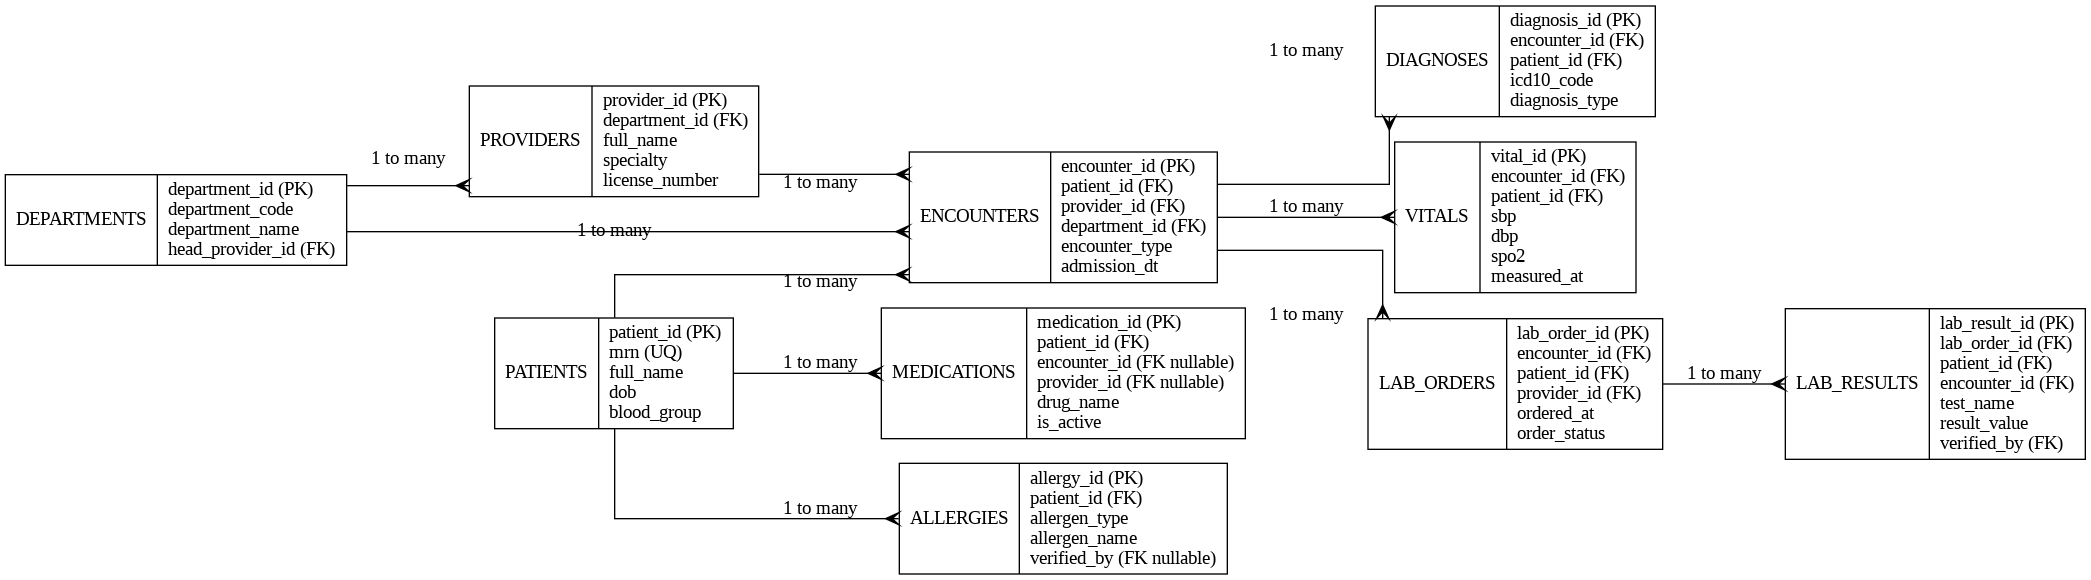

In [41]:
#DB File
!gdown https://drive.google.com/uc?id=1xKaruVDm-bRZkIKUwL4u_l95gGkv9YBg -O EHR_Data.db

#ER Diagram
!gdown https://drive.google.com/uc?id=1lU7ApMffjDlEQIxSRjY1x360LtZhcwLp -O er_diagram_healthcare.png

#Show the ER Diagram
from IPython.display import Image, display
display(Image("er_diagram_healthcare.png"))

## Connect to existing SQLite DB

In [42]:
#Step-1: Database Connection
# Connect to existing SQLite DB -EHR database
from sqlalchemy import create_engine
engine = create_engine("sqlite:///EHR_Data.db")

# Create LangChain SQL Database object -wraps DB for LangChain
from langchain_community.utilities import SQLDatabase
db = SQLDatabase(
    engine,
    sample_rows_in_table_info=3
)

SQLAlchemy is a popular Python library used to work with databases. It acts as a middle layer between:
* Python code
* SQL databases like SQLite, MySQL, PostgreSQL, Oracle, SQL Server

Instead of manually handling raw database connections and SQL operations, SQLAlchemy provides easier and more structured ways to interact with databases.

create_engine() is a SQLAlchemy function used to create a connection engine to the database.

SQLDatabase is a LangChain wrapper around the database connection. It converts the normal SQL database into a format that LangChain agents and tools can understand.

sample_rows_in_table_info=3 tells LangChain to include 3 sample rows from each table while generating schema information.



**Print Database Details**

In [ ]:
print("Dialect:", db.dialect)

In [ ]:
tables = db.get_usable_table_names()
print(tables)

In [ ]:
SCHEMA = db.get_table_info()
print(SCHEMA)

## LLM

In [ ]:
#Step-2 : Define LLM
llm=ChatOpenAI()

## State

In [ ]:
#Step-3: Define State
class my_message_state(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

#LangGraph Built-in Class, It contains the reducer function internally.
from langgraph.graph import MessagesState

In [ ]:
print(my_message_state.__annotations__)

In [ ]:
print(MessagesState.__annotations__)

## Get tools from SQLDatabaseToolkit

This creates the standard LangChain SQL tools.

The toolkit automatically gives tools like:
```
sql_db_list_tables
sql_db_schema
sql_db_query
sql_db_query_checker
```
These tools save us from writing custom SQL tools manually.

In [ ]:
#Step-4: Get tools from SQLDatabaseToolkit
from langchain_community.agent_toolkits import SQLDatabaseToolkit
toolkit = SQLDatabaseToolkit(db=db, llm=llm)
all_tools = toolkit.get_tools()
print(all_tools)

#Print Tool Names
for tool in all_tools:
    print(tool.name)

In [ ]:
tool_dict = {}
for tool in all_tools:
  tool_dict[tool.name] = tool

In [ ]:
list_tables_tool = tool_dict["sql_db_list_tables"]
get_schema_tool = tool_dict["sql_db_schema"]
run_query_tool = tool_dict["sql_db_query"]
query_checker_tool = tool_dict["sql_db_query_checker"]

## Create Nodes

### List tables Node

This is the first node in the graph. It lists all tables in the database. The code manually creates a tool call for sql_db_list_tables.

Then it invokes the tool. Finally, it stores the table list as a message. This message becomes part of the graph state.

The LLM can use this information in the next steps

In [ ]:
#Step-5: list_tables node
def list_tables(state: MessagesState):
    print("---LIST TABLES---")
    result = list_tables_tool.invoke({})

    return {
        "messages": [
            AIMessage(content=str(result))
        ]
    }

In [ ]:
sample_state = {
    "messages": [
        HumanMessage(content="How many patients are there?")
    ]
}

output1 = list_tables(sample_state)
print(output1["messages"][-1].content)

sample_state["messages"].extend(output1["messages"])

### Get Schema Node

This node asks the model to decide which table schemas are needed. The model already knows the user question and available tables. So it chooses the relevant table or tables.

In [ ]:
#Step-6: get_schema node
def get_schema(state: MessagesState):
    print("---GET SCHEMA---")
    table_names_text = state["messages"][-1].content

    result = get_schema_tool.invoke({
        "table_names": table_names_text
    })

    return {
        "messages": [
            AIMessage(content=f"Database schema:\n{result}")
        ]
    }

In [ ]:
#Testing
output2 = get_schema(sample_state)
print(output2["messages"][-1].content)

sample_state["messages"].extend(output2["messages"])

### Generate SQL query Node

This is an LLM node that looks at the Uesr Question and the Schema to genrate the SQL query

In [ ]:
#Step-7: generate_query node
def generate_query(state: MessagesState):
    print("---GENERATE QUERY---")
    question = state["messages"][0].content
    schema = state["messages"][-1].content

    prompt = f"""
    You are a SQL expert.
    Generate a correct SQL query using the schema below.

    Question:
    {question}

    Schema:
    {schema}

    Rules:
    - Use only SELECT queries.
    - Do not use INSERT, UPDATE, DELETE, DROP, ALTER, or CREATE.
    - Use only the tables and columns present in the schema.
    - Return only the SQL query.
    """
    result = llm.invoke(prompt)

    return {
        "messages": [
            AIMessage(content=result.content)
        ]
    }

In [ ]:
#Testing
sample_state = {
    "messages": [
        HumanMessage(content="How many patients are there?")
    ]
}

output3 = generate_query(sample_state)
print(output3["messages"][-1].content)

sample_state["messages"].extend(output3["messages"])

### Execute Query node

This node executes the Generated Query

In [ ]:
#Step-8: execute_query node
def execute_query(state: MessagesState):
    print("---EXECUTE QUERY---")
    sql_query = state["messages"][-1].content

    result = run_query_tool.invoke(sql_query)

    return {
        "messages": [
            AIMessage(content=f"Query result:\n{result}")
        ]
    }

In [ ]:
# Test Node
output4 = execute_query(sample_state)
print(output4["messages"][-1].content)

## Build The Graph

This function builds the LangGraph workflow. MessagesState means the graph state is mainly a list of messages.

Each node reads messages and adds new messages.

In [ ]:
#Step-9: Build the Graph
builder = StateGraph(MessagesState)

# Nodes
builder.add_node("list_tables", list_tables)
builder.add_node("get_schema", get_schema)
builder.add_node("generate_query", generate_query)
builder.add_node("execute_query", execute_query)

#Edges
builder.add_edge(START, "list_tables")
builder.add_edge("list_tables", "get_schema")
builder.add_edge("get_schema", "generate_query")
builder.add_edge("generate_query", "execute_query")
builder.add_edge("execute_query", END)

#Compile
sql_agent=builder.compile()
sql_agent

##Run the Graph

In [ ]:
#Step-10: Invoke the Graph
question = "How many patients are there?"
result=sql_agent.invoke({"messages": [HumanMessage(content=question)]})
print(result["messages"][-1].content)

In [ ]:
question="""What is the count of providers in each department ?
and show me top 5 department by name and count
"""
result=sql_agent.invoke({"messages": [HumanMessage(content=question)]})
print(result["messages"][-1].content)

## Testcases

In [ ]:
test_questions = [
    "What is the count of patients by gender?",
    "What are the top 5 departments with the highest number of providers?",
    "How many encounters are recorded for each encounter type?",
    "What is the average age of patients by gender?",
    "List the top 5 most frequently diagnosed conditions along with their counts."
]

for i, question in enumerate(test_questions, start=1):
    print("\n" + "=" * 80)
    print(f"TEST CASE {i}: {question}")
    print("=" * 80)

    result = sql_agent.invoke({
        "messages": [HumanMessage(content=question)]
    })

    print(result["messages"][-1].content)

# Example-11: Human In The Loop [HITL]

Human-in-the-Loop (HITL) is a workflow design pattern where an AI system pauses at critical steps and waits for human input, approval, correction, or guidance before continuing execution.

## Memory

When execution pauses for human approval, LangGraph must remember:

current node,
messages,
generated SQL query,
current workflow position.

Without a checkpointer, the graph cannot resume later.


In [ ]:
#Step-1: Memory
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

##State with Approval

In [ ]:
#Step-2: Extend the State. Add one more key - Approved(bool)
class SQLAgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    approved: bool

## HITL Logic

``interrupt()`` immediately pauses the LangGraph workflow. Think of it like ``input("Approve the Query")`` but designed for LangGraph workflows.

Later, the graph resumes using:```Command(resume="yes")``` Then:human_response becomes:"yes"

In [ ]:
#Step-3: Create HITL function by using inturrupt() function

from langgraph.types import interrupt, Command
def approve_query(state: SQLAgentState):
    print("---HUMAN APPROVAL---")
    sql_query = state["messages"][-1].content

    human_response = interrupt(
        "Approve the Query"
    )

    if str(human_response).lower().strip() in ["yes", "y", "approve", "approved"]:
        return {"approved": True}

    return {
        "approved": False,
        "messages": [
            AIMessage(content="Query execution cancelled by human.")
        ]
    }

In [ ]:
#Step-4: Router function after approval
def route_after_approval(state: SQLAgentState):
    if state["approved"]:
        return "execute_query"
    else:
        return END

## Graph

In [ ]:
#Step-5: Rebuild the Graph include HITL
builder = StateGraph(SQLAgentState)

builder.add_node("list_tables", list_tables)
builder.add_node("get_schema", get_schema)
builder.add_node("generate_query", generate_query)
builder.add_node("approve_query", approve_query)
builder.add_node("execute_query", execute_query)

builder.add_edge(START, "list_tables")
builder.add_edge("list_tables", "get_schema")
builder.add_edge("get_schema", "generate_query")
builder.add_edge("generate_query", "approve_query")

builder.add_conditional_edges(
    "approve_query",
    route_after_approval,
    {
        "execute_query": "execute_query",
        END: END
    }
)
builder.add_edge("execute_query", END)
sql_agent = builder.compile(checkpointer=memory)
sql_agent

## Invoke the Graph

In [ ]:
#Step-6: Invoke
question = "How many patients are there?"

config = {
    "configurable": {
        "thread_id": "sql_approval_1"
    }
}

result = sql_agent.invoke(
    {"messages": [HumanMessage(content=question)]},
    config=config
)

print(result["messages"][-1].content)

In [ ]:
#Step-7: Human Approves
result = sql_agent.invoke(
    Command(resume="yes"),
    config=config
)

print(result["messages"][-1].content)

In [ ]:
#Step-7: Human Rejects
question = "How many patients are there?"
config = {
    "configurable": {
        "thread_id": "sql_approval_1"
    }
}

result = sql_agent.invoke(
    {"messages": [HumanMessage(content=question)]},
    config=config
)

result = sql_agent.invoke(
    Command(resume="no"),
    config=config
)
print(result["messages"][-1].content)

In [ ]:
def user_q_and_a(question):
  config = {
    "configurable": {
        "thread_id": "sql_approval_1"
    }
  }
  result = sql_agent.invoke(
    {"messages": [HumanMessage(content=question)]},
    config=config
  )
  print("\n ====This is the Query==== \n")
  print(result["messages"][-1].content)
  if "__interrupt__" in result:
    human_input = input("\nExecute query? (yes/no): ")

    #Resume graph
    result = sql_agent.invoke(
        Command(resume=human_input),
        config=config
    )
    return result["messages"][-1].content
  else:
    return result["messages"][-1].content

In [ ]:
question="How many patients are there?"
user_q_and_a(question)

In [ ]:
question="Delete the table patients"
user_q_and_a(question)

## Gradio

In [ ]:
#Gradio UI

import gradio as gr
from langchain_core.messages import HumanMessage
from langgraph.types import Command

config = {
    "configurable": {
        "thread_id": "demo"
    }
}

waiting_for_approval = False


def chat(message, history):
    global waiting_for_approval

    # Resume after approval
    if waiting_for_approval:
        result = sql_agent.invoke(
            Command(resume=message),
            config=config
        )
        waiting_for_approval = False
        reply = result["messages"][-1].content
        return reply

    # Normal query
    result = sql_agent.invoke(
        {
            "messages": [
                HumanMessage(content=message)
            ]
        },
        config=config
    )

    # HITL interrupt
    if "__interrupt__" in result:
        waiting_for_approval = True
        # The sql_query is the content of the last message in the state before interrupt
        sql_query = result["messages"][-1].content
        return f"""
        Approval Required

        SQL Query:
        {sql_query}

        Type yes or no
        """

    return result["messages"][-1].content


gr.ChatInterface(chat).launch()

#Example-12: MultiTool AI Agent

Please follow the below link for the complete source code, detailed explanation, and end-to-end step-by-step workflow.

**Code File Link - [Click Here](https://colab.research.google.com/drive/1KVcu0Q4tcYjOrs6Be9LK9BZ2iurdRAUX?pli=1&usp=drive_fs#scrollTo=eGkX_qv--HpV)**